In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#replacing blanks with 0 as tenure is 0 and no total charges recorded
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
#checking null values
df.isnull().sum().sum()

np.int64(0)

In [7]:
#describing data
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df["customerID"].duplicated().sum()

np.int64(0)

In [9]:
#function for replcationg int to txt
def conv(value):
    if value==1:
        return "yes"
    else:
        return "no"
df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)
    

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


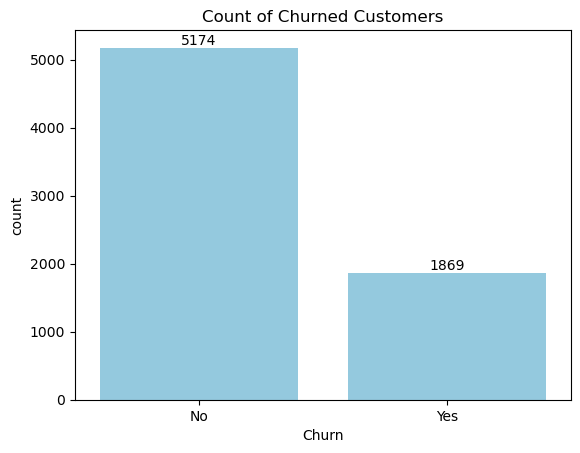

In [27]:
#how many customers have churned out
ax=sns.countplot(x='Churn',data=df, color="skyblue")
ax.bar_label(ax.containers[0])
plt.title("Count of Churned Customers")
plt.show()

### Most customers stayed with the company, but a significant number still left, indicating room to improve customer retention.

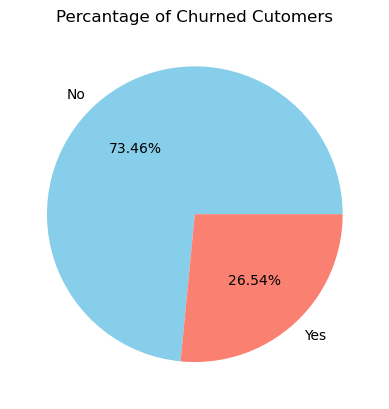

In [34]:
#in percentage wise
gb=df.groupby('Churn').agg({'Churn':"count"})
plt.pie(gb['Churn'],labels=gb.index,autopct='%1.2f%%',colors=["skyblue","salmon"])
plt.title("Percantage of Churned Cutomers")
plt.show()

### Around one-quarter of customers churned, meaning nearly 1 in 4 customers stopped using the service.

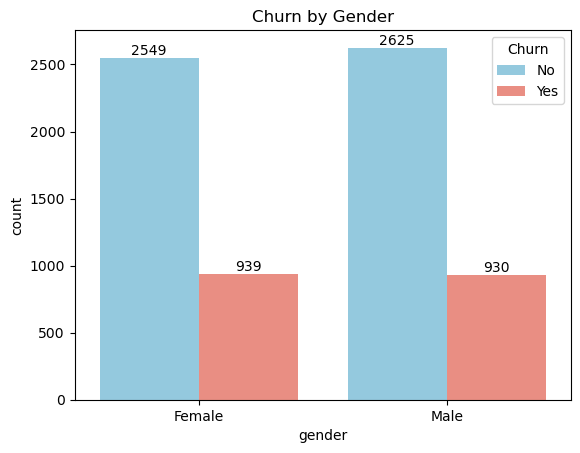

In [29]:
ax=sns.countplot(x="gender",data=df,hue="Churn",palette=["skyblue", "salmon"])
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.title("Churn by Gender",fontsize=12)
plt.show()

### Male and female customers show very similar churn behavior, so gender has little impact on customer retention.

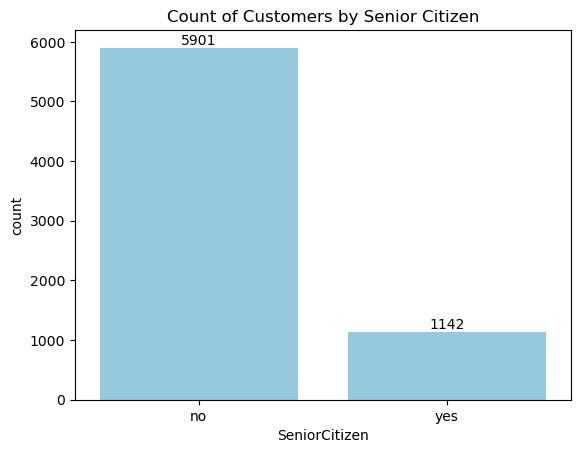

In [28]:
ax=sns.countplot(x="SeniorCitizen",data=df, color="skyblue")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen",fontsize=12)
plt.show()

### The customer base mainly consists of non-senior citizens.

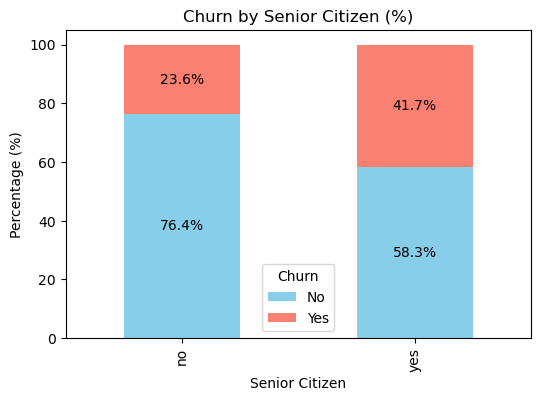

In [15]:
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

# Plot
ct.plot(kind="bar",
        stacked=True,
        figsize=(6,4),
        color=["skyblue", "salmon"])

plt.title("Churn by Senior Citizen (%)")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

# Add percentage labels
for c in plt.gca().containers:
    plt.gca().bar_label(c, fmt='%.1f%%', label_type='center', color='black')

plt.show()

### Senior citizens have a higher churn rate than non-senior customers, making them a higher-risk customer segment.

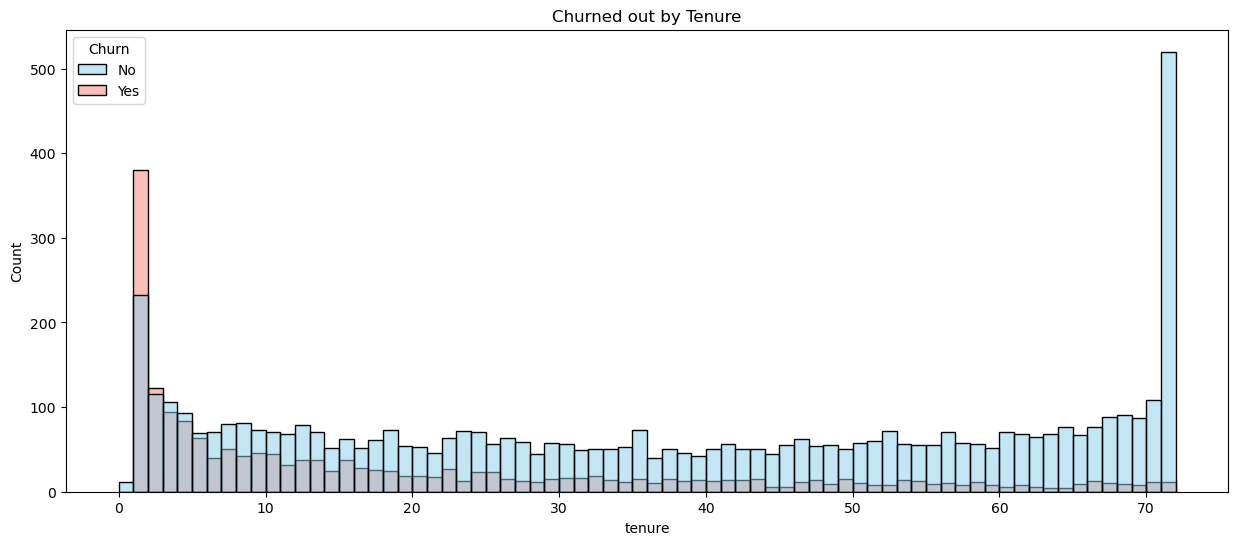

In [33]:
plt.figure(figsize=(15,6))
sns.histplot(x="tenure",data=df,bins=72,hue="Churn",palette=["skyblue","salmon"])
plt.title("Churned out by Tenure")
plt.show()

### Most customers who churn leave within the early months, while long-term customers are more likely to stay.

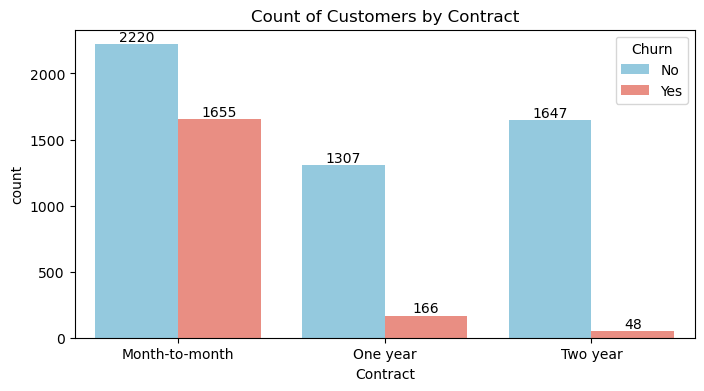

In [31]:
plt.figure(figsize=(8,4))
ax=sns.countplot(x="Contract",data=df,hue="Churn",palette=["skyblue", "salmon"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by Contract",fontsize=12)
plt.show()

### Customers with month-to-month contracts churn much more than those with longer-term contracts.

In [18]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

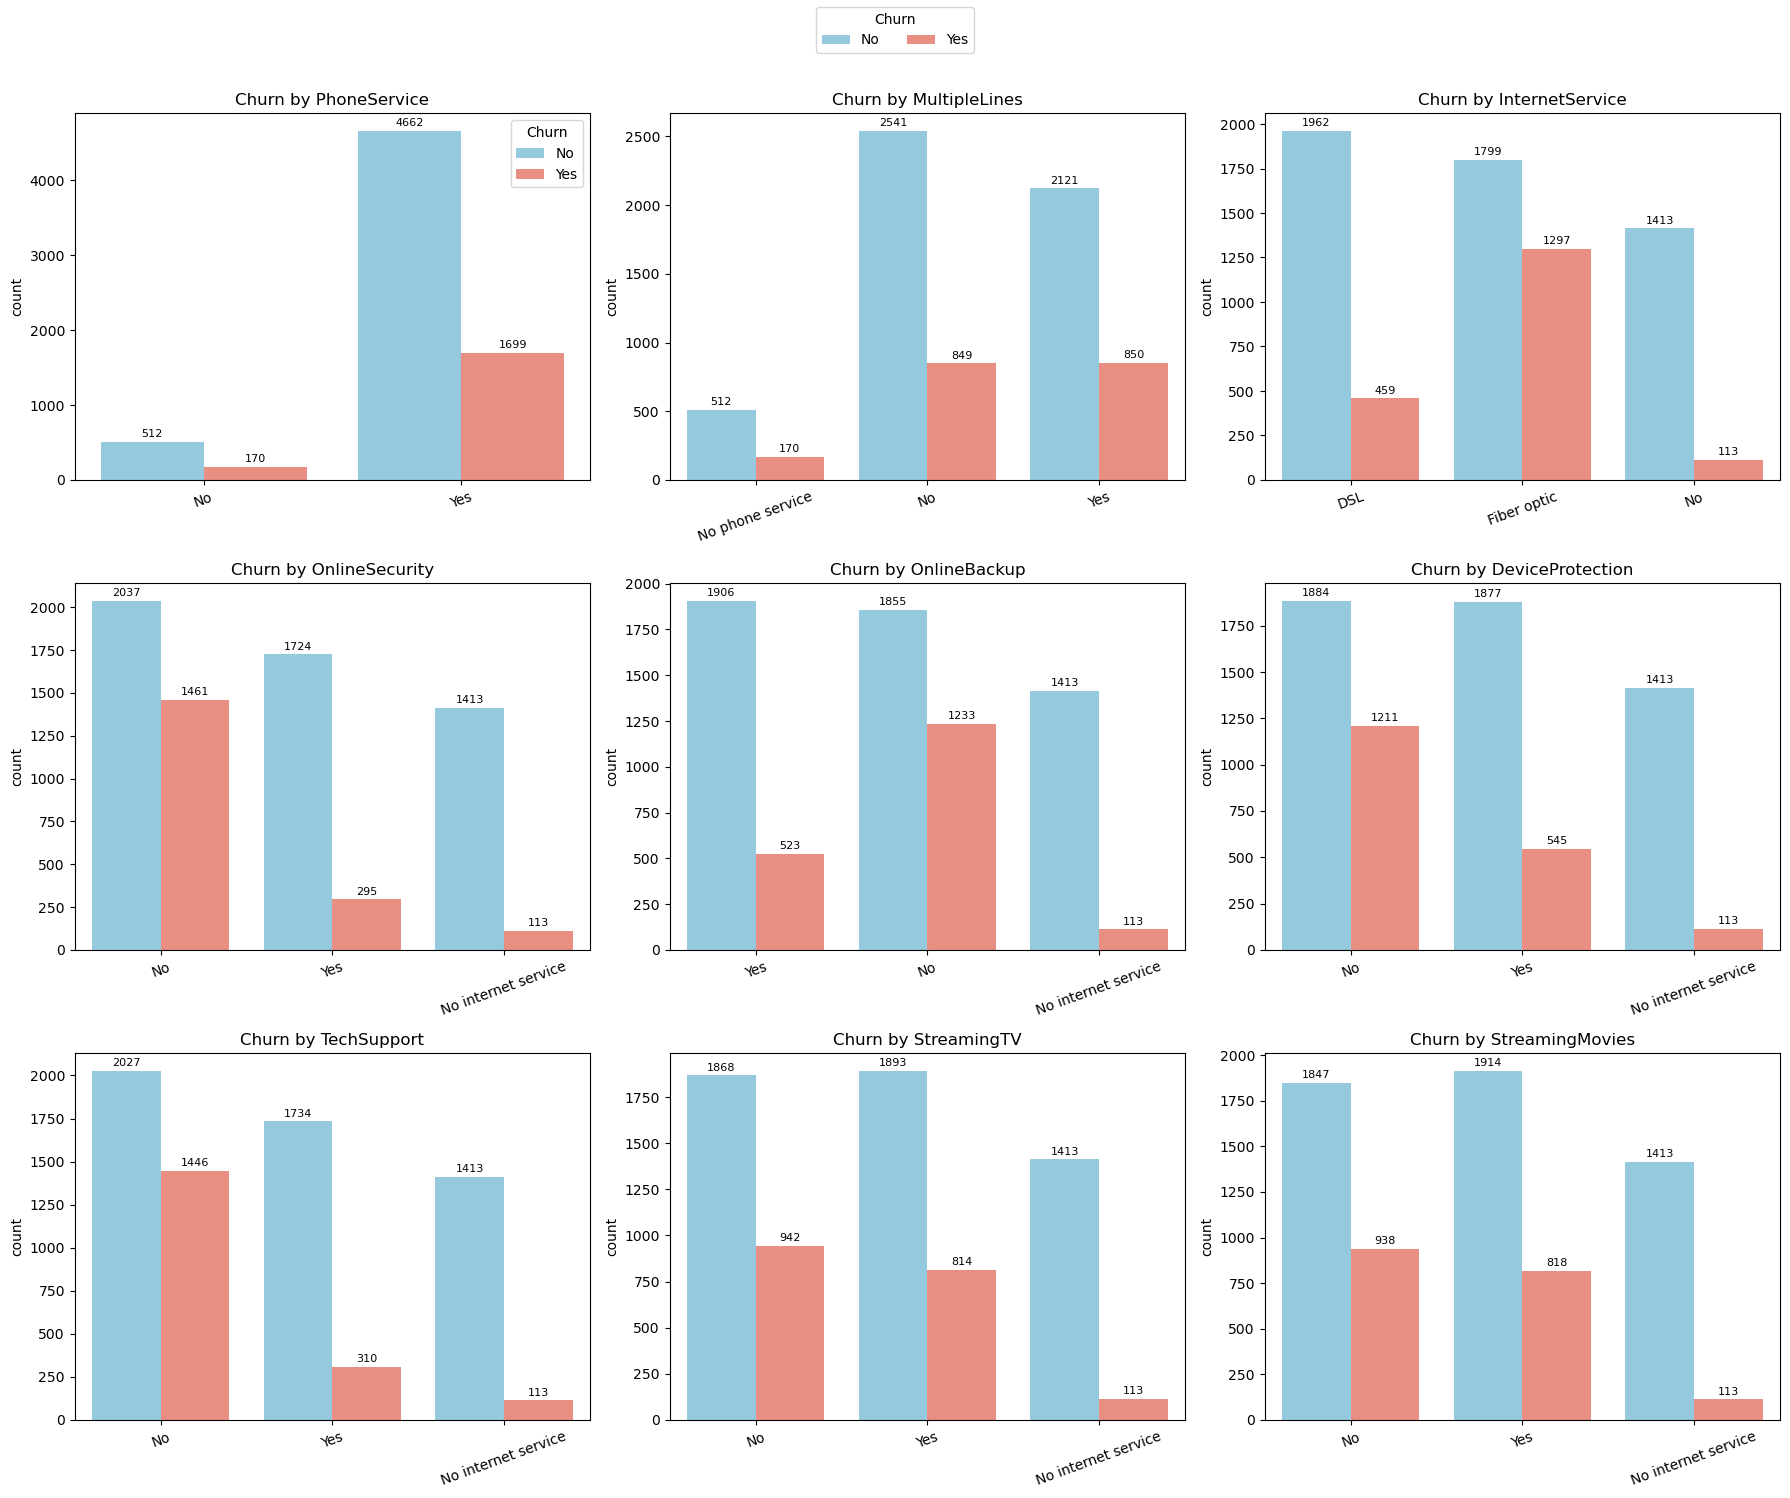

In [41]:
# Columns to plot
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=axes[i],
        palette=["skyblue", "salmon"]
    )

    # Add data labels on every bar
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%d',
            fontsize=8,
            padding=2
        )

    ax.set_title(f'Churn by {col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

    # Keep legend only on the first subplot
    if i != 0:
        ax.legend_.remove()

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Churn',
           loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Customers without value-added services like Online Security and Tech Support tend to churn more frequently.

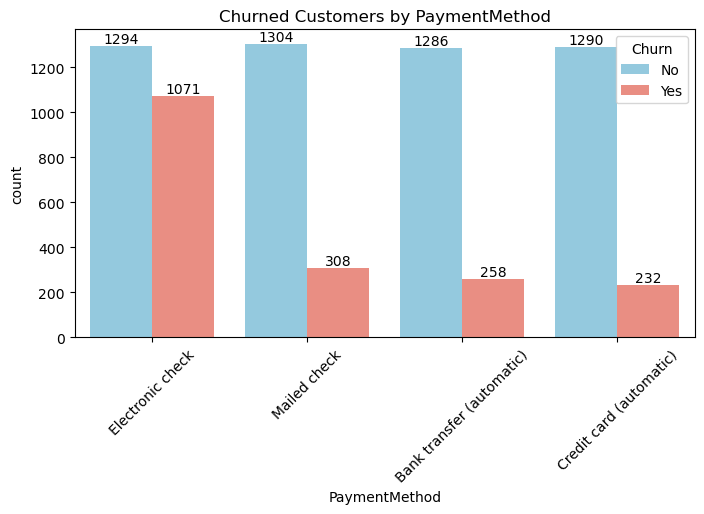

In [32]:
plt.figure(figsize=(8,4))
ax=sns.countplot(x="PaymentMethod",data=df,hue="Churn",palette=["skyblue", "salmon"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by PaymentMethod",fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Customers paying through electronic checks have the highest churn, while automatic payment methods show better customer retention.